# TFP Swap Spread Mean-Reversion Backtest

Trades deviations of maturity-matched swap spreads from the fitted term structure.

**Strategy**: When a tenor's deviation z-score exceeds a threshold, enter a BPV-neutral swap spread trade:
- **Deviation too negative** (spread too wide): *receive in spread* = buy bond + receive fixed in swap
- **Deviation too positive** (spread too narrow): *pay in spread* = sell bond + pay fixed in swap

Exit when z-score mean-reverts to zero (or max holding period).

Treasury leg financed at GC repo rate + specialness.

In [31]:
%load_ext autoreload
%autoreload 2

import datetime
import sys
import os

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import pandas as pd
import numpy as np
import QuantLib as ql

plt.style.use('ggplot')
pylab.rcParams.update({
    'legend.fontsize': 'x-large',
    'figure.figsize': (18, 8),
    'axes.labelsize': 'x-large',
    'axes.titlesize': 'x-large',
    'xtick.labelsize': 'large',
    'ytick.labelsize': 'large',
})

sys.path.append('../../')

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from BT.query_tearsheet import QueryBacktestTearSheet

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from Query.FixedRateBonds.carry_roll import load_us_treasury_gc_fixing_pct
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

from BT.signals.tfp_swap_spread import (
    BENCHMARK_TENORS,
    CT_MAP,
    build_tfp_history,
    compute_deviation_zscores,
    generate_signals,
    extract_entry_exit_events,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [32]:
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

# Backtest period
BT_START = datetime.date(2021, 6, 1)
BT_END = datetime.date(2026, 5, 14)

# Signal lookback for z-score warm-up — history starts earlier
SIGNAL_START = datetime.date(2021, 1, 1)

# Risk
RISK_BPV = 100_000
UNWIND_FEE_BPS = 0.5

# Signal thresholds
ZSCORE_WINDOW = 60
Z_ENTRY = 1.5
Z_EXIT = 0.0

# Which tenors to trade
TRADE_TENORS = ['2Y', '5Y', '10Y', '30Y']

# Financing
SPECIALNESS_BPS = 10.0

# Cache
CACHE_PATH = os.path.abspath(
    os.path.join(os.getcwd(), '..', '..', 'BT', 'results', 'tfp_screener', 'tfp_history.parquet')
)

print(f'Backtest: {BT_START} to {BT_END}')
print(f'Trade tenors: {TRADE_TENORS}')
print(f'Signal: z_entry={Z_ENTRY}, z_exit={Z_EXIT}, window={ZSCORE_WINDOW}d')

Backtest: 2021-06-01 to 2026-05-14
Trade tenors: ['2Y', '5Y', '10Y', '30Y']
Signal: z_entry=1.5, z_exit=0.0, window=60d


## Load / Compute TFP History & Signals

Loads cached data from the screener if available, otherwise computes from scratch.

In [33]:
curve_mdp = IRSwapsMDP(source='ERIS_EOD_LIVE-RL_BASIC')
usts_mdp = FixedRateBondsMDP(source='USTS_FEDINVEST_WSJ_LIVE-RL')

history = build_tfp_history(
    start_date=SIGNAL_START,
    end_date=BT_END,
    curve_mdp=curve_mdp,
    usts_mdp=usts_mdp,
    cache_path=CACHE_PATH,
    show_progress=True,
)
history = history.loc[BT_START:BT_END]
print(f'TFP history: {len(history)} days, {history.index.min()} to {history.index.max()}')
history

TFP history: 1239 days, 2021-06-01 00:00:00 to 2026-05-14 00:00:00


,tfp,zds,slope,r_squared,mmss_10Y,dur_10Y,baseline_10Y,dev_10Y,mmss_2Y,dur_2Y,...,baseline_5Y,dev_5Y,mmss_7Y,dur_7Y,baseline_7Y,dev_7Y,mmss_20Y,dur_20Y,baseline_20Y,dev_20Y
date,,,,,,,,,,,,,,,,,,,,,
2021-06-01,2.585779,-0.351624,-2.585779,0.963566,-26.271918,9.148915,-24.008700,-2.263217,-5.298726,1.991114,...,-13.000019,1.964790,-23.482611,6.676084,-17.614505,-5.868106,-50.452446,16.015119,-41.763189,-8.689256
2021-06-02,2.607383,0.633280,-2.607383,0.968178,-25.002995,9.148314,-23.219879,-1.783116,-2.412383,1.988697,...,-12.114618,0.407757,-22.668180,6.674433,-16.769525,-5.898655,-49.938553,16.019293,-41.135156,-8.803398
2021-06-03,2.544403,-0.884519,-2.544403,0.972993,-24.825055,9.142667,-24.147145,-0.677910,-4.971779,1.985657,...,-13.314529,0.741798,-23.462652,6.669848,-17.855297,-5.607355,-50.012779,16.010653,-41.622065,-8.390713
2021-06-04,2.539289,-0.723162,-2.539289,0.975275,-24.970653,9.140261,-23.932927,-1.037726,-4.266727,1.977627,...,-13.111464,0.622191,-22.958563,6.664890,-17.647245,-5.311318,-49.278069,16.030694,-41.429728,-7.848341
2021-06-07,2.474505,-1.373141,-2.474505,0.975827,-24.509110,9.136991,-23.982676,-0.526433,-5.468137,1.974743,...,-13.438251,0.778917,-23.058048,6.661773,-17.857735,-5.200313,-48.963665,16.022969,-41.022065,-7.941600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-08,4.006263,-10.066711,-4.006263,0.998721,-41.404614,7.871864,-41.603469,0.198855,-16.704807,1.879383,...,-27.985286,-0.528079,-35.191996,5.994132,-34.080781,-1.111214,-67.133446,12.587843,-60.496921,-6.636525
2026-05-11,3.983380,-12.520426,-3.983380,0.997834,-43.262718,7.863837,-43.845077,0.582359,-18.908454,1.876278,...,-30.318871,0.053402,-37.939666,5.988699,-36.375690,-1.563976,-70.589922,12.564517,-62.569671,-8.020251
2026-05-12,4.130415,-9.979172,-4.130415,0.996979,-41.864600,7.854808,-42.422784,0.558184,-16.915295,1.873174,...,-28.417093,0.153205,-36.921184,5.982626,-34.689897,-2.231288,-70.223320,12.534090,-61.750161,-8.473159


In [34]:
zscores = compute_deviation_zscores(history, window=ZSCORE_WINDOW, tenors=TRADE_TENORS)
signals = generate_signals(zscores, z_entry=Z_ENTRY, z_exit=Z_EXIT, tenors=TRADE_TENORS)

# Filter to backtest period
signals = signals.loc[BT_START:BT_END]
zscores = zscores.loc[BT_START:BT_END]

# Extract entry/exit events
all_events = []
for tenor in TRADE_TENORS:
    events = extract_entry_exit_events(signals, tenor)
    all_events.extend(events)
    print(f'{tenor}: {len(events)} trades')

print(f'\nTotal trades: {len(all_events)}')

2Y: 53 trades
5Y: 51 trades
10Y: 37 trades
30Y: 35 trades

Total trades: 176


## Initialize MDPs & Financing

In [35]:
frb_mdp = FixedRateBondsMDP(source='USTS_FEDINVEST_WSJ_LIVE-QL')
irs_mdp = IRSwapsMDP(source='ERIS_EOD_LIVE-RL_BASIC')

# Time grid: all business days in backtest range
tg = TimeGrid(
    ql_cal_date_range(ql_cal=CAL, start=BT_START, end=BT_END)
)

# GC fixing rates for treasury financing
gc_fixing_pct = pd.Series(
    {d: load_us_treasury_gc_fixing_pct(d)
     for d in sorted({ts.date() for ts in tg})},
    dtype=float,
).sort_index()

gc_fixing_pct = gc_fixing_pct.ffill().bfill()
print(f'GC fixing range: {gc_fixing_pct.min():.2f}% to {gc_fixing_pct.max():.2f}%')

# Financing config — gc_rate is a Series, handler indexes by date
financing_config = {
    'mode': 'gc_plus_specialness',
    'gc_rate': gc_fixing_pct / 100.0,
    'leg_specialness_bps': {'outright': SPECIALNESS_BPS},
    'day_count': 'ACT/360',
    'haircut': 0.0,
}

GC fixing range: 0.01% to 5.40%


## Build Triggers

Each trade event creates two triggers:
1. **Entry**: `DateTrigger` with two `AddQueryAction`s (bond leg + swap leg)
2. **Exit**: `DateTrigger` with `UnwindPositionsAction` matching the trade tag

Bond leg carries financing config. Swap leg is unfunded.

In [36]:
triggers = []

for ev in all_events:
    tenor = ev['tenor']
    direction = ev['direction']  # +1=receive spread, -1=pay spread
    tag = ev['tag']
    entry_d = ev['entry_date']
    exit_d = ev['exit_date']
    ct = CT_MAP[tenor]

    bond_bpv = RISK_BPV * direction
    swap_bpv = -RISK_BPV * direction

    # Bond leg: CT alias, with financing
    bond_query = FixedRateBondQuery(
        cusip=ct,
        value=FixedRateBondValue.NPV,
        structure_kwargs={'bpv': bond_bpv},
        meta={'financing': financing_config},
        tags=(tag,),
    )

    # Swap leg: tenor-matched, unfunded
    swap_query = IRSwapQuery(
        curve='USD-SOFR-1D',
        tenor=tenor,
        value=IRSwapValue.NPV,
        structure_kwargs={'bpv': swap_bpv},
        tags=(tag,),
    )

    # Entry trigger: open both legs
    entry_trigger = DateTrigger(
        DateTriggerRequirements(dates=[entry_d]),
        actions=[
            AddQueryAction(query=bond_query),
            AddQueryAction(query=swap_query),
        ],
    )

    # Exit trigger: unwind both legs by tag
    exit_trigger = DateTrigger(
        DateTriggerRequirements(dates=[exit_d]),
        actions=[
            UnwindPositionsAction(
                match_tag=tag,
                fee=UNWIND_FEE_BPS * RISK_BPV,
            ),
        ],
    )

    triggers.extend([entry_trigger, exit_trigger])

print(f'Built {len(triggers)} triggers ({len(all_events)} trades x 2)')

Built 352 triggers (176 trades x 2)


## Run Backtest

In [37]:
strategy = QueryStrategy(
    name='TFP Swap Spread Mean Reversion',
    triggers=triggers,
    mdps={'FRB': frb_mdp, 'IRS': irs_mdp},
)

bt = QueryDrivenBacktest(
    time_grid=tg,
    strategy=strategy,
)

bt.run()

BACKTESTING...:  18%|█▊        | 222/1239 [00:34<02:13,  7.63step/s]

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2022-04-15 00:00:00')] not in index"


BACKTESTING...:  38%|███▊      | 477/1239 [01:21<00:23, 32.20step/s]WARNING	Task(Task-2) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- Failed to fetch pricer for CT2 @ 2023-05-03: 'No FedInvest snapshot for 2023-05-03 (key: 2023-05-03 00:00:00)'
WARNING	Task(Task-2) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- Failed to fetch pricer for 91282CGX3 @ 2023-05-03: 'No FedInvest snapshot for 2023-05-03 (key: 2023-05-03 00:00:00)'
WARNING	Task(Task-2) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- Failed to fetch pricer for CT2 @ 2023-05-04: 'No FedInvest snapshot for 2023-05-04 (key: 2023-05-04 00:00:00)'
WARNING	Task(Task-2) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- Failed to fetch pricer for 91282CGX3 @ 2023-05-04: 'No FedInvest snapshot for 2023-05-04 (key: 2023-05-04 00:00:00)'
BACKTESTING...:  39%|███▉      | 482/1239 [01:22<01:10, 10.78step/s]

"Missing FRB pricer for leg cusip='CT2'. available=[]"
"Missing FRB pricer for leg cusip='CT2'. available=[]"
"Missing FRB pricer for leg cusip='CT2'. available=[]"


BACKTESTING...:  79%|███████▊  | 973/1239 [02:58<00:42,  6.21step/s]

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2025-04-18 00:00:00')] not in index"


BACKTESTING...:  98%|█████████▊| 1211/1239 [03:49<00:05,  5.41step/s]

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2026-02-16 00:00:00'), Timestamp('2026-04-03 00:00:00')] not in index"


BACKTESTING...: 100%|██████████| 1239/1239 [03:53<00:00,  5.31step/s]


## Results: MTM P&L

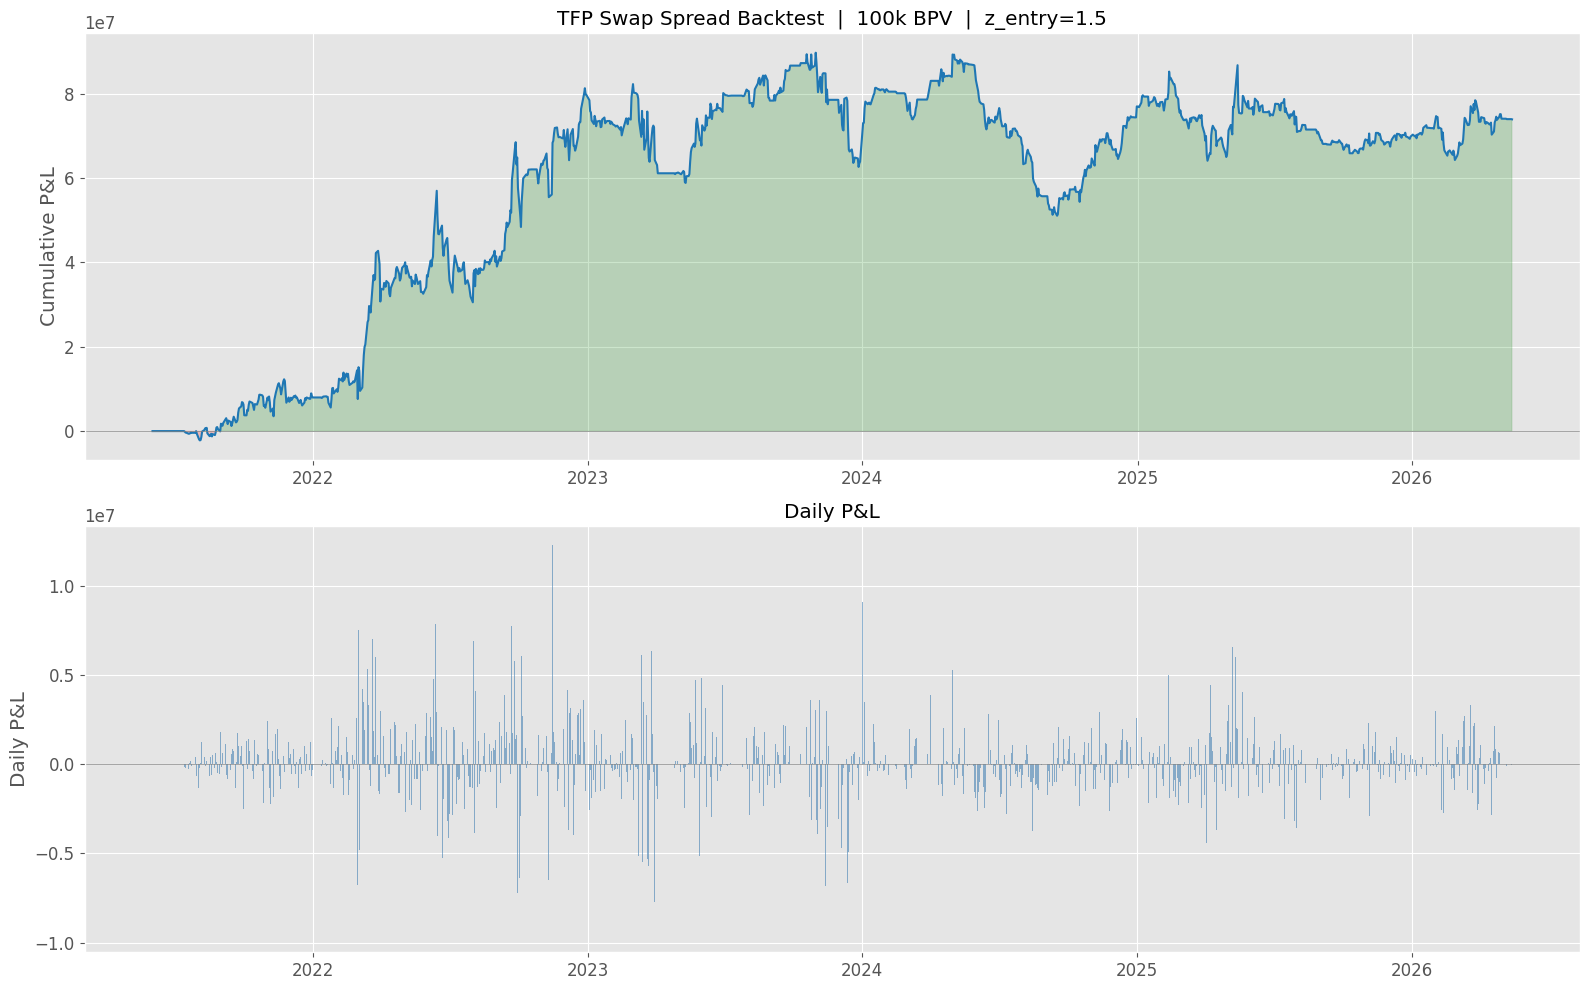

In [38]:
mtm = pd.Series(bt.mtm_history).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax = axes[0]
ax.plot(mtm.index, mtm.values, linewidth=1.5, color='#1f77b4')
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_ylabel('Cumulative P&L')
ax.set_title(f'TFP Swap Spread Backtest  |  {RISK_BPV/1000:.0f}k BPV  |  z_entry={Z_ENTRY}')
ax.fill_between(mtm.index, 0, mtm.values,
                where=mtm.values >= 0, alpha=0.2, color='green')
ax.fill_between(mtm.index, 0, mtm.values,
                where=mtm.values < 0, alpha=0.2, color='red')

# Daily P&L
daily_pnl = mtm.diff()
ax = axes[1]
ax.bar(daily_pnl.index, daily_pnl.values, width=1, color='steelblue', alpha=0.6)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_ylabel('Daily P&L')
ax.set_title('Daily P&L')

fig.tight_layout()
plt.show()

## Closed Positions Analysis

In [39]:
closed = pd.DataFrame(bt.portfolio.closed_positions_log)

if not closed.empty:
    def _extract_tag(row):
        # Tags live on source_query.tags, not in position_meta
        sq = row.get('source_query', None)
        if sq is not None and hasattr(sq, 'tags') and sq.tags:
            return sq.tags[0]
        pos = row.get('position', None)
        if pos is not None and hasattr(pos, 'source_query'):
            sq2 = pos.source_query
            if hasattr(sq2, 'tags') and sq2.tags:
                return sq2.tags[0]
        pm = row.get('position_meta', {})
        if isinstance(pm, dict) and 'tags' in pm:
            tags = pm['tags']
            return tags[0] if tags else None
        return None

    closed['tag'] = closed.apply(_extract_tag, axis=1)

    trade_pnl = closed.dropna(subset=['tag']).groupby('tag').agg(
        realized_pnl=('realized_pnl', 'sum'),
        holding_days=('holding_period_days', 'mean'),
        opened=('opened_at', 'min'),
        closed=('closed_at', 'max'),
    ).sort_values('opened')

    trade_pnl['tenor'] = trade_pnl.index.str.extract(r'tfp-(\w+)-')[0].values

    n_trades = len(trade_pnl)
    n_winners = (trade_pnl['realized_pnl'] > 0).sum()
    avg_win = trade_pnl.loc[trade_pnl['realized_pnl'] > 0, 'realized_pnl'].mean()
    avg_loss = trade_pnl.loc[trade_pnl['realized_pnl'] <= 0, 'realized_pnl'].mean()

    print(f'Trades: {n_trades}')
    print(f'Winners: {n_winners} ({n_winners/n_trades:.0%})')
    if pd.notna(avg_win): print(f'Avg win:  {avg_win:,.0f}')
    if pd.notna(avg_loss): print(f'Avg loss: {avg_loss:,.0f}')
    print(f'Avg holding: {trade_pnl["holding_days"].mean():.0f} days')
    print(f'Total P&L: {trade_pnl["realized_pnl"].sum():,.0f}')
    print()

    tenor_summary = trade_pnl.groupby('tenor').agg(
        n_trades=('realized_pnl', 'count'),
        total_pnl=('realized_pnl', 'sum'),
        avg_pnl=('realized_pnl', 'mean'),
        hit_rate=('realized_pnl', lambda x: (x > 0).mean()),
        avg_days=('holding_days', 'mean'),
    )
    display(tenor_summary)
else:
    print('No closed trades yet.')

Trades: 176
Winners: 101 (57%)
Avg win:  2,698,139
Avg loss: -2,586,989
Avg holding: 22 days
Total P&L: 78,487,864



,n_trades,total_pnl,avg_pnl,hit_rate,avg_days
tenor,,,,,
10Y,37,-1.099882e+07,-2.972655e+05,0.513514,27.216216
2Y,53,3.227885e+07,6.090350e+05,0.622642,18.679245
30Y,35,5.046449e+05,1.441842e+04,0.485714,28.742857
5Y,51,5.670319e+07,1.111827e+06,0.627451,18.235294


## Trade Timeline

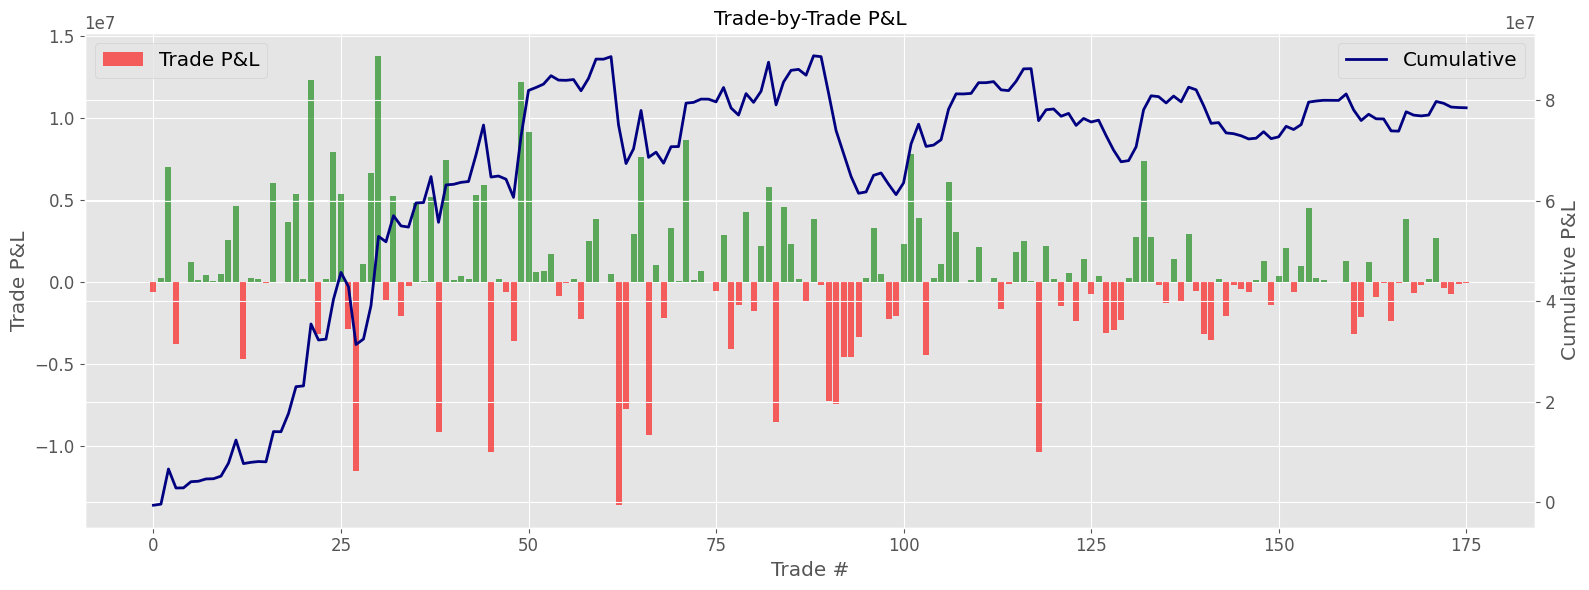

In [40]:
if not closed.empty and len(trade_pnl) > 0:
    fig, ax = plt.subplots(figsize=(16, 6))

    cum_pnl = trade_pnl['realized_pnl'].cumsum()
    colors = ['green' if p > 0 else 'red' for p in trade_pnl['realized_pnl']]

    ax.bar(range(len(cum_pnl)), trade_pnl['realized_pnl'].values,
           color=colors, alpha=0.6, label='Trade P&L')
    ax2 = ax.twinx()
    ax2.plot(range(len(cum_pnl)), cum_pnl.values,
             color='navy', linewidth=2, label='Cumulative')

    ax.set_xlabel('Trade #')
    ax.set_ylabel('Trade P&L')
    ax2.set_ylabel('Cumulative P&L')
    ax.set_title('Trade-by-Trade P&L')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    fig.tight_layout()
    plt.show()

## Signal vs P&L Overlay

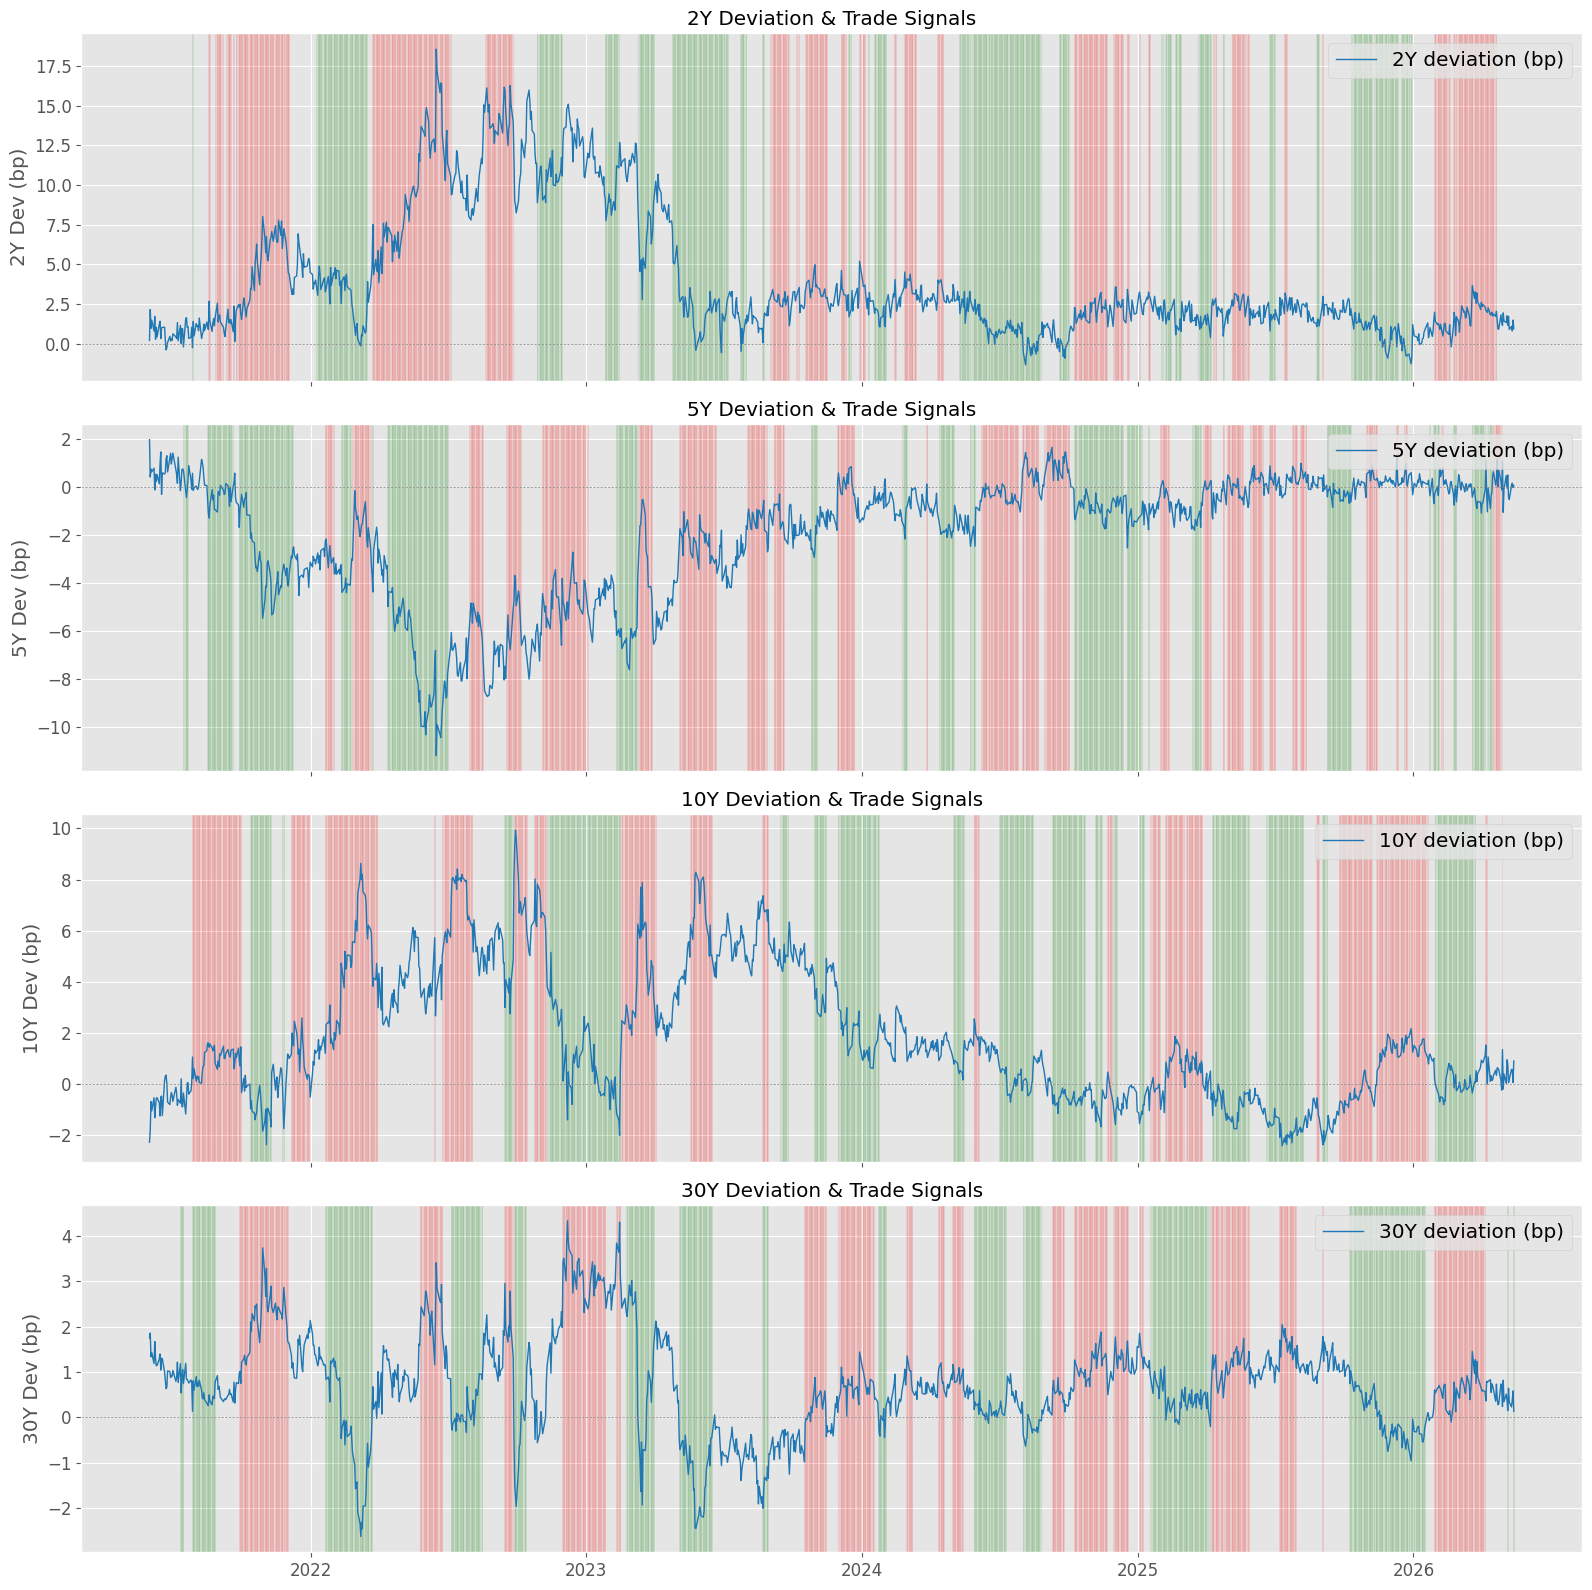

In [41]:
n_tenors = len(TRADE_TENORS)
fig, axes = plt.subplots(n_tenors, 1, figsize=(16, 4 * n_tenors), sharex=True)
if n_tenors == 1:
    axes = [axes]

history_bt = history.loc[BT_START:BT_END]

for ax, tenor in zip(axes, TRADE_TENORS):
    dev_col = f'dev_{tenor}'
    z_col = f'z_{tenor}'

    if dev_col in history_bt.columns:
        ax.plot(history_bt.index, history_bt[dev_col], color='#1f77b4',
                linewidth=1, label=f'{tenor} deviation (bp)')
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')

    # Shade signal periods
    sig_col = f'sig_{tenor}'
    if sig_col in signals.columns:
        sig = signals[sig_col]
        for i in range(1, len(sig)):
            if sig.iloc[i] == 1:
                ax.axvspan(sig.index[i-1], sig.index[i],
                           alpha=0.1, color='green')
            elif sig.iloc[i] == -1:
                ax.axvspan(sig.index[i-1], sig.index[i],
                           alpha=0.1, color='red')

    ax.set_ylabel(f'{tenor} Dev (bp)')
    ax.set_title(f'{tenor} Deviation & Trade Signals')
    ax.legend(loc='upper right')

fig.tight_layout()
plt.show()

## Tearsheet

In [42]:
try:
    tearsheet = QueryBacktestTearSheet.from_backtest(bt)
    plotly_fig = tearsheet.plot_plotly()
    plotly_fig.show()
except Exception as e:
    print(f'Tearsheet generation: {e}')
    # Fallback: basic stats
    if len(mtm) > 1:
        daily = mtm.diff().dropna()
        sharpe = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
        max_dd = (mtm - mtm.cummax()).min()
        print(f'\nFinal P&L:  {mtm.iloc[-1]:,.0f}')
        print(f'Sharpe:     {sharpe:.2f}')
        print(f'Max DD:     {max_dd:,.0f}')
        print(f'Daily vol:  {daily.std():,.0f}')

## Financing Cost Decomposition

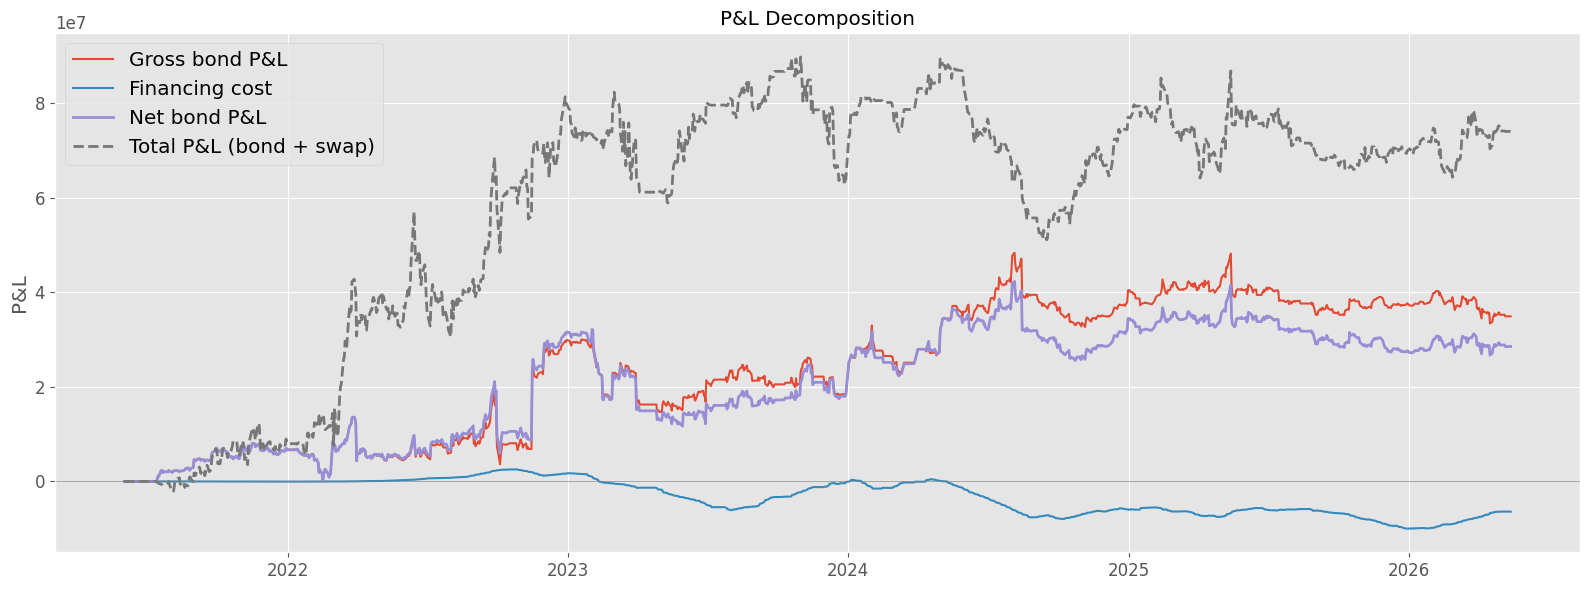

In [43]:
component_histories = getattr(bt, 'frb_component_histories', {})

if component_histories:
    time_index = pd.Index(list(tg), name='date')

    gross_bond = pd.Series(
        component_histories.get('bond_total', {}), dtype=float
    ).sort_index().reindex(time_index).ffill().fillna(0.0)

    financing = pd.Series(
        component_histories.get('financing_total', {}), dtype=float
    ).sort_index().reindex(time_index).ffill().fillna(0.0)

    net = pd.Series(
        component_histories.get('net_total', {}), dtype=float
    ).sort_index().reindex(time_index).ffill().fillna(0.0)

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(gross_bond.index, gross_bond.values, label='Gross bond P&L')
    ax.plot(financing.index, financing.values, label='Financing cost')
    ax.plot(net.index, net.values, label='Net bond P&L', linewidth=2)
    ax.plot(mtm.index, mtm.values, label='Total P&L (bond + swap)', linewidth=2, linestyle='--')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_ylabel('P&L')
    ax.set_title('P&L Decomposition')
    ax.legend(loc='best')
    fig.tight_layout()
    plt.show()
else:
    print('No FRB component history available — total MTM only.')